# 2 · Models

A **model** maps parameters + observation times/bands to predicted flux. WHISPER ships several and lets you register your own. `predict(params, times, bands) -> flux [Jy]` is the whole contract; the samplers call it.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import whisper_labia as wp

wp.list_models()

['bazin', 'flare', 'gaussian_rise', 'mck19', 'two_component_kilonova']

## Evaluate a built-in model

`get_model` returns a `Model`; `.predict` evaluates it. `bazin` is an empirical supernova light-curve shape (band-independent here).

parameters: ['amplitude', 't0', 'tau_rise', 'tau_fall']


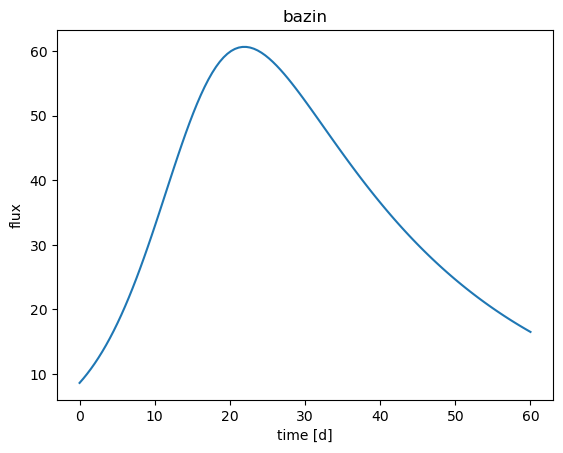

In [2]:
bazin = wp.get_model('bazin')
print('parameters:', bazin.parameters)

t = np.linspace(0, 60, 120)
theta = {'amplitude': 100.0, 't0': 15.0, 'tau_rise': 5.0, 'tau_fall': 25.0}
flux = bazin.predict(theta, t, bands=None)

plt.plot(t, flux); plt.xlabel('time [d]'); plt.ylabel('flux'); plt.title('bazin');

## Physical models

`mck19` (AGN-disk BBH flare) and `two_component_kilonova` (NS–NS merger, via the optional **redback** backend) are physically parametrised and band-dependent. The kilonova needs `bands` and returns flux density in Jy.

In [3]:
kn = wp.get_model('two_component_kilonova')
print('parameters:', kn.parameters)

t = np.linspace(0.5, 15, 40)
theta = dict(mej_1=0.02, vej_1=0.25, temperature_floor_1=3000,
             mej_2=0.05, vej_2=0.15, temperature_floor_2=1200,
             kappa_1=0.5, kappa_2=3.0, redshift=0.0098)
for b in ['g', 'r', 'i']:
    f = kn.predict(theta, t, bands=[b] * len(t))
    plt.plot(t, -2.5 * np.log10(f / 3631), label=b)
plt.gca().invert_yaxis(); plt.xlabel('days'); plt.ylabel('AB mag'); plt.legend();

parameters: ['mej_1', 'vej_1', 'kappa_1', 'temperature_floor_1', 'mej_2', 'vej_2', 'kappa_2', 'temperature_floor_2', 'redshift']


/opt/conda/lib/python3.11/site-packages/lalsimulation/lalsimulation.py:8: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


14:03 bilby INFO    : Running bilby version: 2.8.0


14:03 redback INFO    : Running redback version: 1.12.0


Error in callback <function _draw_all_if_interactive at 0x7a10c2982c00> (for post_execute), with arguments args (),kwargs {}:


RuntimeError: Failed to process string with tex because latex could not be found

RuntimeError: Failed to process string with tex because latex could not be found

<Figure size 640x480 with 1 Axes>

## Register your own

`register_model(name, predict, parameters, prior=...)` adds a model to the registry so every sampler can use it by name. The `predict` signature is fixed; `prior` is an optional default.

In [4]:
def line_flux(p, times, bands=None):
    return p['slope'] * np.asarray(times, float) + p['intercept']

wp.register_model('line', line_flux, ['slope', 'intercept'],
                  prior=wp.Prior({'slope': wp.Uniform(-5, 5),
                                  'intercept': wp.Uniform(-10, 10)}),
                  overwrite=True)
print('line' in wp.list_models(), '->', wp.get_model('line').parameters)

True -> ['slope', 'intercept']


**Next:** [3 · Samplers](03_samplers.ipynb) — fitting a model to data.